# Bước 1: Làm sạch dữ liệu và Khám phá dữ liệu (EDA)

**Bộ dữ liệu**: 541.909 giao dịch từ một nhà bán lẻ online ở UK (tháng 12/2010 - tháng 12/2011)

**Notebook này gồm:**
1. Tải và kiểm tra dữ liệu thô
2. Làm sạch: loại bỏ hoá đơn bị huỷ, giao dịch non-UK, hàng không hợp lệ
3. Khám phá dữ liệu (EDA): xu hướng doanh thu, thời gian mua hàng, sản phẩm bán chạy, hành vi khách hàng
4. RFM cơ bản làm nền so sánh cho bước feature engineering
5. Xuất dữ liệu sạch cho notebook tiếp theo

## Cài đặt

In [1]:
%load_ext autoreload
%autoreload 2

# Import libraries
import sys
sys.path.append('../src')

from clustering_library import DataCleaner, DataVisualizer, compute_rfm
from notebook_io import wpath, rpath   # manual runs write to data/_sandbox, never canonical
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [2]:
# Set up chart style
visualizer = DataVisualizer()

## Tải dữ liệu

In [3]:
# Load the Online Retail dataset
data_path = "../data/raw/online_retail.csv"

# Initialise data cleaner and load data
cleaner = DataCleaner(data_path)
df = cleaner.load_data()

# Display first rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,017850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,017850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,017850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,017850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,017850,United Kingdom


In [4]:
# Check basic dataset information
print("Dataset overview:")
print(f"- Size: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"- Missing values: {df.isnull().sum().sum():,}")
print(f"- Unique customers: {df['CustomerID'].nunique():,}")

df.info()

Dataset overview:
- Size: 541,909 rows x 8 columns
- Missing values: 136,534
- Unique customers: 4,372
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


## Làm sạch dữ liệu

Các bước làm sạch:
1. Thêm cột `TotalPrice` (Quantity x UnitPrice)
2. Loại bỏ hoá đơn huỷ (bắt đầu bằng `'C'`)
3. Lọc chỉ giữ khách hàng UK
4. Loại bỏ dòng thiếu `CustomerID`
5. Loại bỏ dòng có Quantity hoặc UnitPrice không hợp lệ

In [5]:
# Clean the data
df_uk = cleaner.clean_data()

# Create time features for analysis
cleaner.create_time_features()

print("Data cleaning results:")
print(f"- Raw data: {df.shape[0]:,} transactions")
print(f"- Clean data: {df_uk.shape[0]:,} transactions")
print(f"- Removed: {df.shape[0] - df_uk.shape[0]:,} transactions ({((df.shape[0] - df_uk.shape[0])/df.shape[0]*100):.1f}%)")
print(f"- UK customers: {df_uk['CustomerID'].nunique():,}")

df_uk.head()

Data cleaning results:
- Raw data: 541,909 transactions
- Clean data: 354,321 transactions
- Removed: 187,588 transactions (34.6%)
- UK customers: 3,920


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,HourOfDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,017850,United Kingdom,15.30,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,017850,United Kingdom,22.00,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8


## Khám phá dữ liệu cơ bản

Sau khi làm sạch, ta khám phá các xu hướng và hành vi trong dữ liệu khách hàng.

### Doanh thu theo thời gian

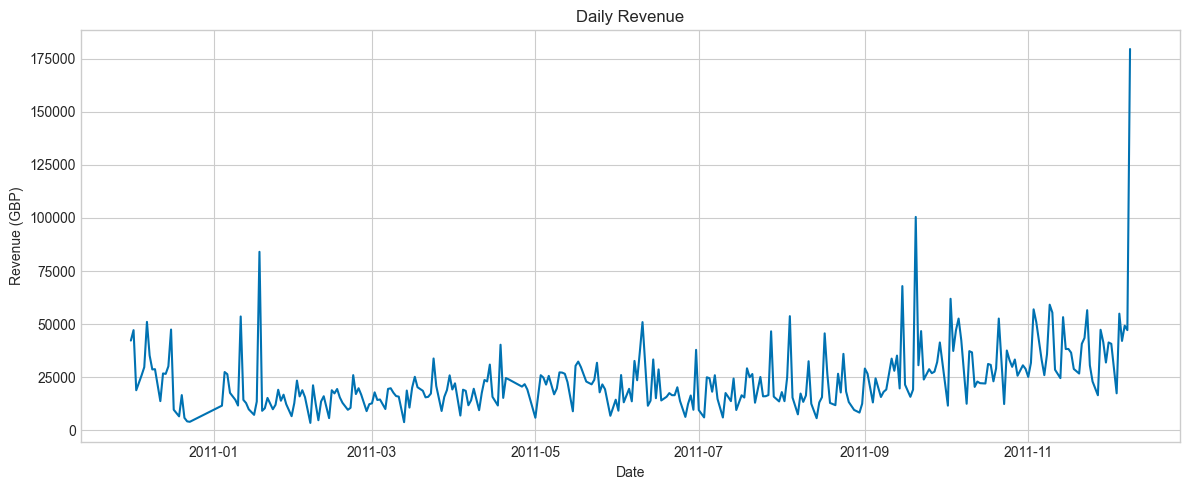

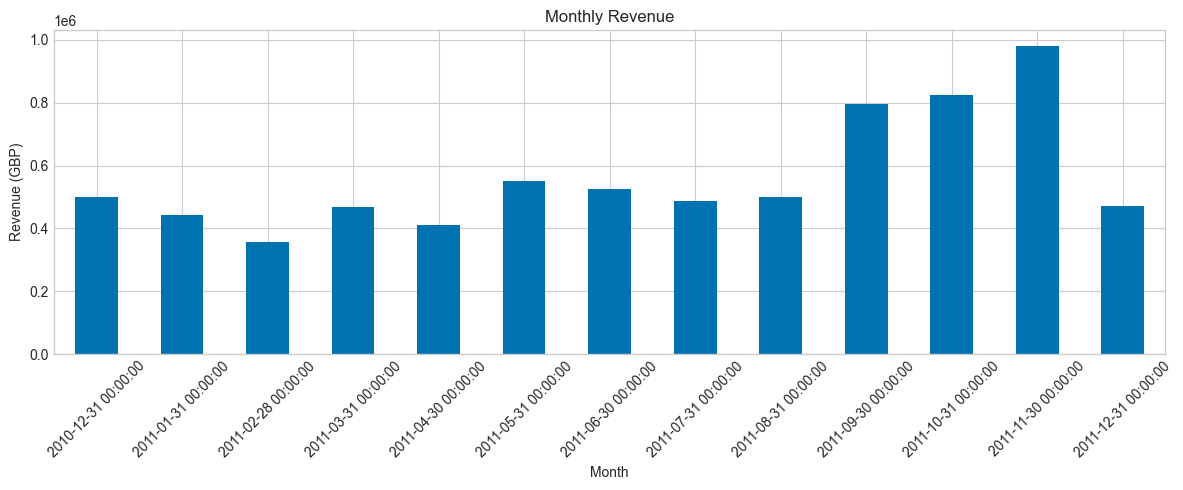

In [6]:
# Plot revenue over time
visualizer.plot_revenue_over_time(df_uk)

### Mẫu thời gian mua hàng

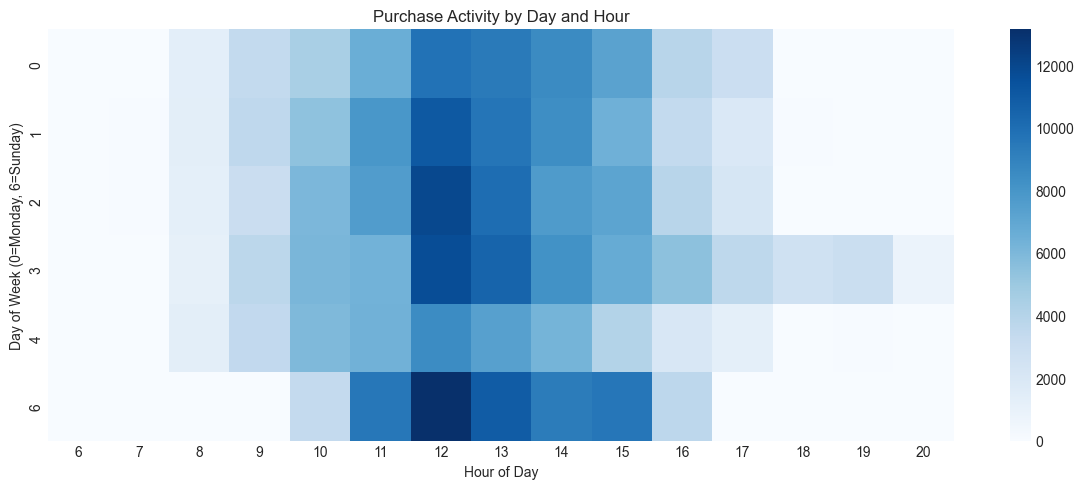

In [7]:
# Analyse purchase time patterns
visualizer.plot_time_patterns(df_uk)

### Xuất hình minh hoạ cho slide bài giảng

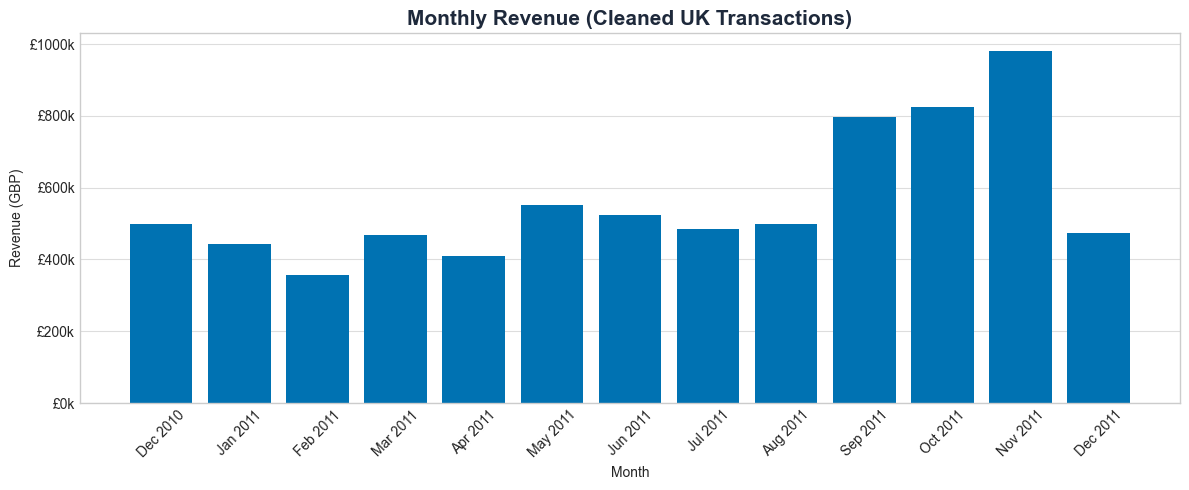

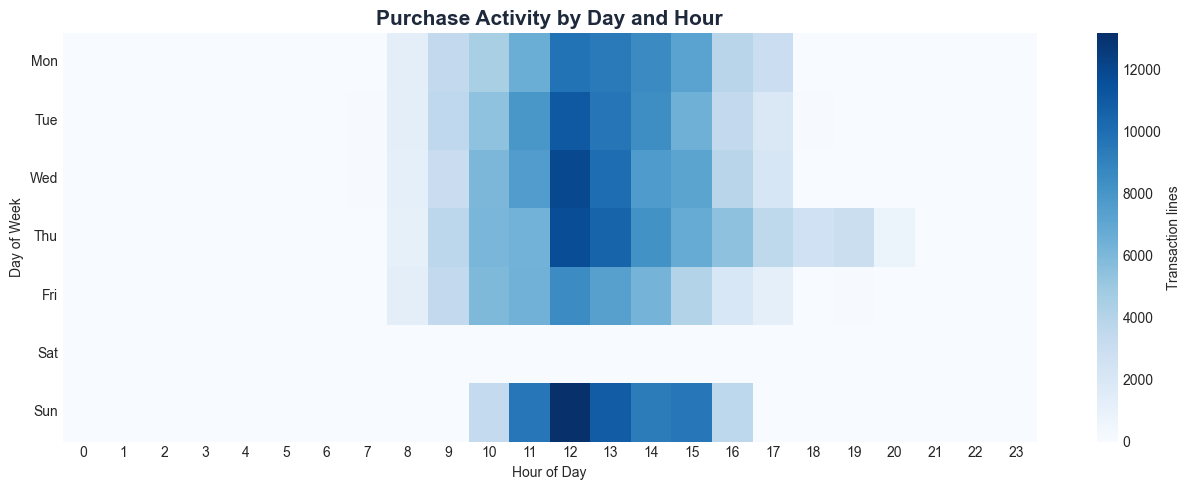

Saved EDA figures:
- ../figures/01_eda/monthly_revenue.png
- ../figures/01_eda/purchase_activity_day_hour.png


In [8]:
# Export EDA figures used in lecture slides
figure_dir = Path("../figures/01_eda")
figure_dir.mkdir(parents=True, exist_ok=True)

# Monthly revenue: supports Slide 2.4 (Q4 seasonality signal)
monthly_revenue = df_uk.groupby(pd.Grouper(key="InvoiceDate", freq="ME"))["TotalPrice"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    [date.strftime("%b %Y") for date in monthly_revenue.index],
    monthly_revenue.values,
    color="#0072B2",
)
ax.set_title("Monthly Revenue (Cleaned UK Transactions)", fontsize=15, weight="bold", color="#1E293B")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (GBP)")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(lambda value, _: f"£{value / 1000:.0f}k")
ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(figure_dir / "monthly_revenue.png", dpi=180, bbox_inches="tight")
plt.show()

# Day-hour heatmap: supports Slide 2.5 (daytime/business-hours activity signal)
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
day_hour_counts = (
    df_uk.groupby(["DayOfWeek", "HourOfDay"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(day_hour_counts, cmap="Blues", ax=ax, cbar_kws={"label": "Transaction lines"})
ax.set_title("Purchase Activity by Day and Hour", fontsize=15, weight="bold", color="#1E293B")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_yticklabels(day_labels, rotation=0)
fig.tight_layout()
fig.savefig(figure_dir / "purchase_activity_day_hour.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved EDA figures:")
print(f"- {figure_dir / 'monthly_revenue.png'}")
print(f"- {figure_dir / 'purchase_activity_day_hour.png'}")

## Phân tích sản phẩm

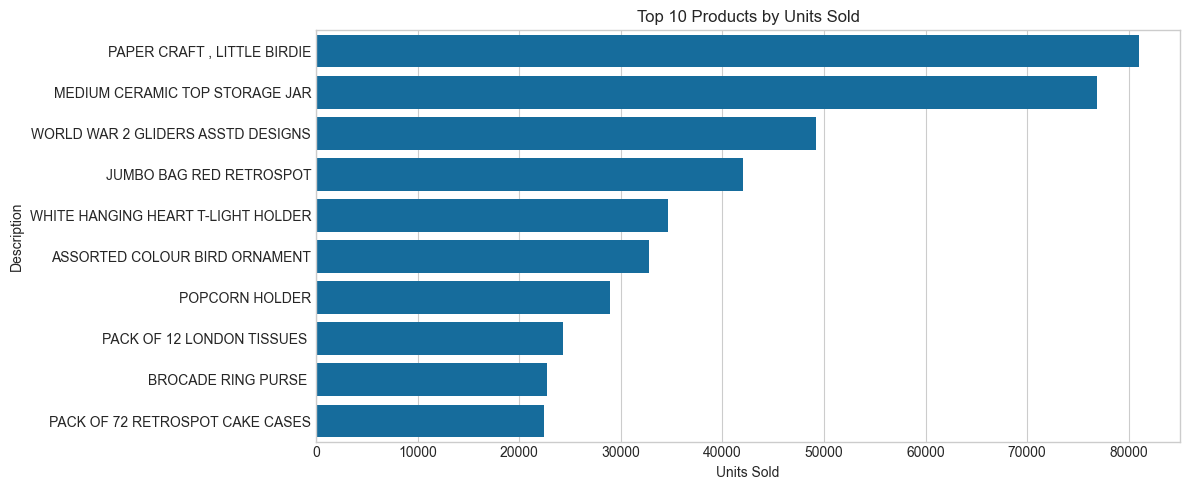

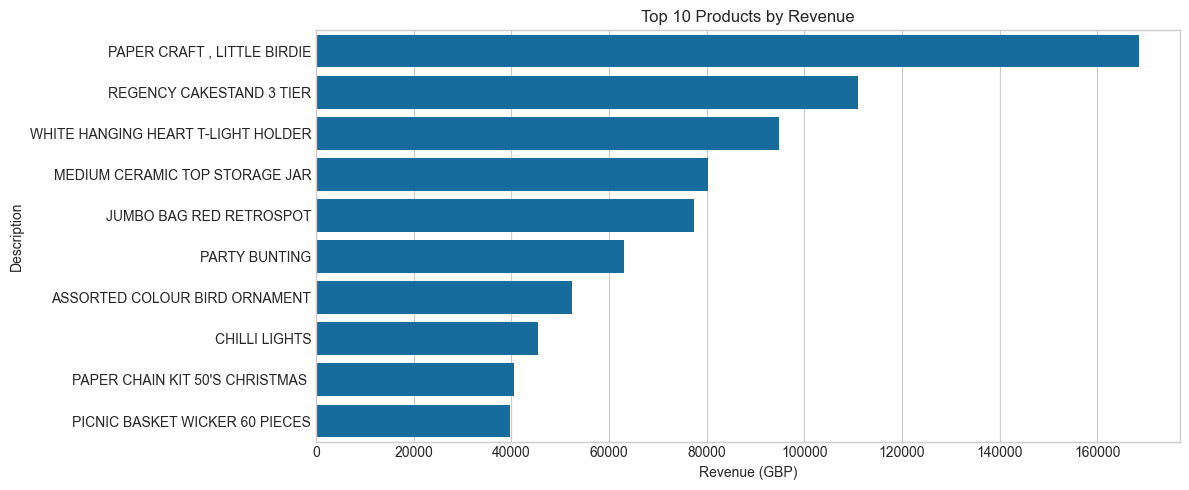

In [9]:
# Top product analysis
visualizer.plot_product_analysis(df_uk)

## Phân tích khách hàng

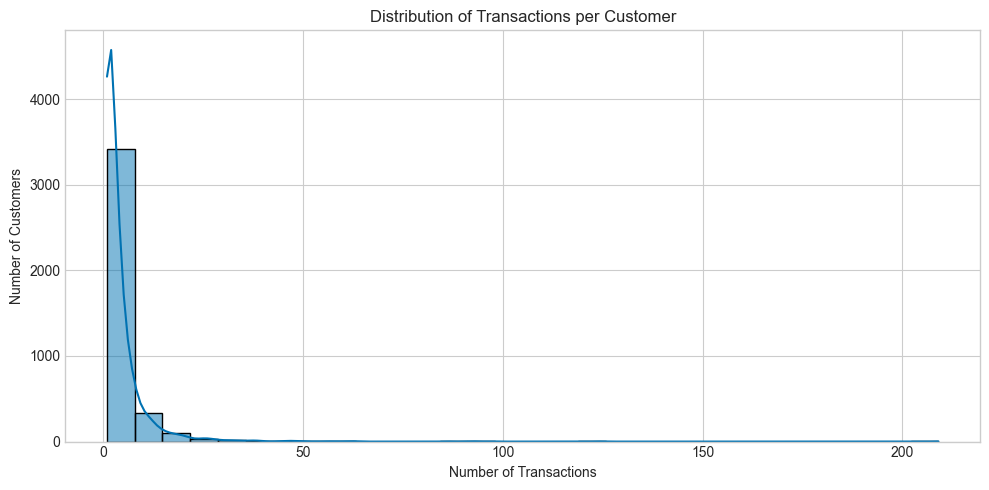

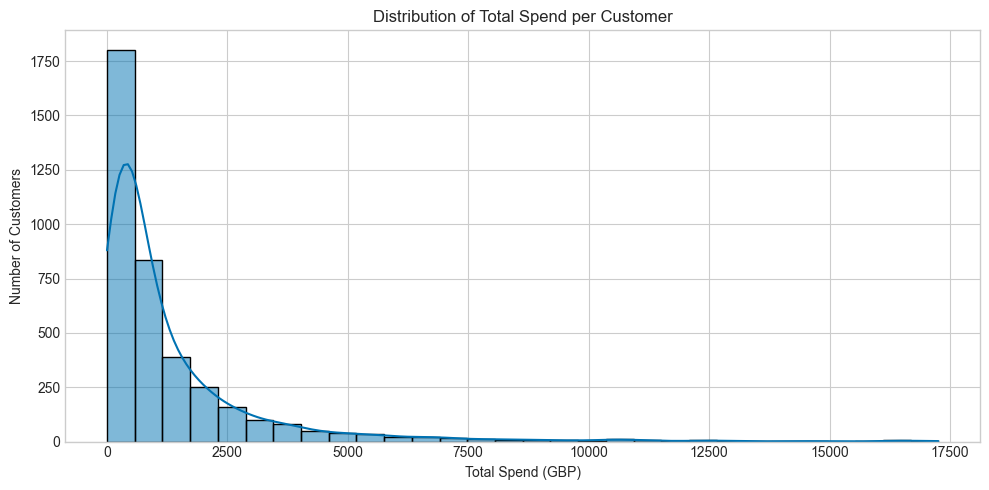

In [10]:
# Customer behaviour distribution analysis
visualizer.plot_customer_distribution(df_uk)

In [11]:
# Customer spending analysis
spend_per_customer = df_uk.groupby("CustomerID")["TotalPrice"].sum()
transactions_per_customer = df_uk.groupby("CustomerID")["InvoiceNo"].nunique()

print("Customer behaviour analysis:")
print(f"- Average spend: £{spend_per_customer.mean():.2f}")
print(f"- Median spend: £{spend_per_customer.median():.2f}")
print(f"- Average transactions: {transactions_per_customer.mean():.1f}")

spend_per_customer.describe()

Customer behaviour analysis:
- Average spend: £1864.39
- Median spend: £652.28
- Average transactions: 4.2


count      3920.000000
mean       1864.385601
std        7482.817477
min           3.750000
25%         300.280000
50%         652.280000
75%        1576.585000
max      259657.300000
Name: TotalPrice, dtype: float64

## Chuẩn bị phân tích RFM

RFM gồm ba chỉ số:
- **Recency**: Khách hàng mua gần đây nhất khi nào?
- **Frequency**: Họ mua bao thường xuyên?
- **Monetary**: Họ chi tiêu bao nhiêu?

In [12]:
# Calculate RFM metrics (Recency, Frequency, Monetary)
rfm_data = compute_rfm(df_uk).set_index('CustomerID')

print("RFM Analysis:")
print(f"- Mean Recency: {rfm_data['Recency'].mean():.0f} days")
print(f"- Mean Frequency: {rfm_data['Frequency'].mean():.1f} transactions")
print(f"- Mean Monetary: £{rfm_data['Monetary'].mean():.2f}")

rfm_data.head(10)

RFM Analysis:
- Mean Recency: 92 days
- Mean Frequency: 4.2 transactions
- Mean Monetary: £1864.39


,Recency,Frequency,Monetary
CustomerID,,,
012346,326,1,77183.60
012747,2,11,4196.01
012748,1,209,33719.73
012749,4,5,4090.88
012820,3,4,942.34
012821,214,1,92.72
012822,71,2,948.88
012823,75,5,1759.50
012824,60,1,397.12


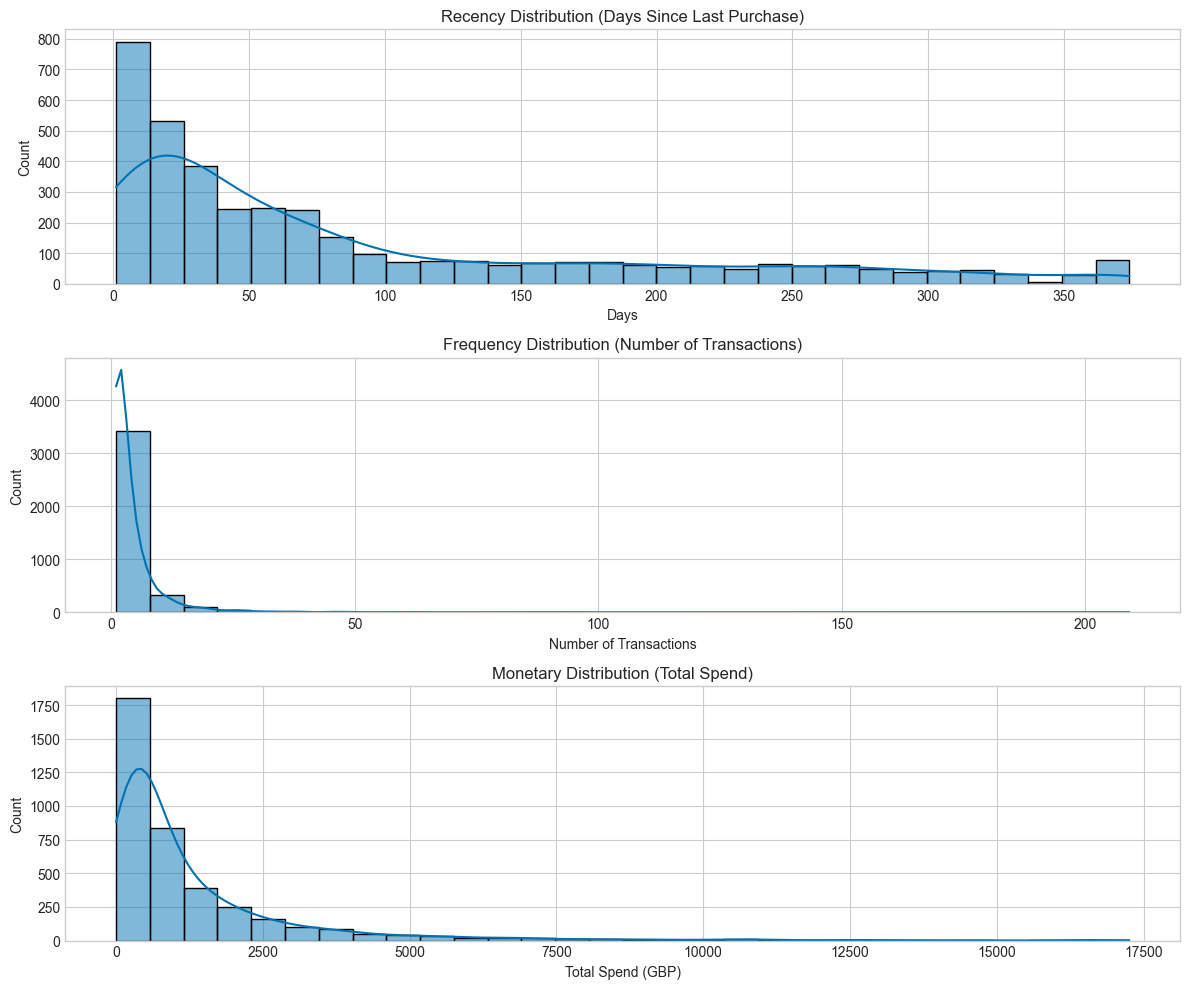

In [13]:
# Visualise RFM distributions
visualizer.plot_rfm_analysis(rfm_data)

## Lưu dữ liệu đã làm sạch

In [14]:
# Save cleaned data (sandbox by default — never overwrites canonical artefacts)
cleaner.save_cleaned_data(wpath("processed"))

print("Data saved successfully:")
print("- File: cleaned_uk_data.csv")
print(f"- Size: {df_uk.shape[0]:,} rows")
print("- Ready for feature engineering")

Data saved successfully:
- File: cleaned_uk_data.csv
- Size: 354,321 rows
- Ready for feature engineering


## Tổng kết

| Chỉ số | Kết quả |
|--------|---------|
| Dữ liệu thô | 541.909 giao dịch |
| Sau làm sạch | **354.321** giao dịch từ **3.920** khách hàng UK |
| Đã loại bỏ | 187.588 (34,6%): hoá đơn huỷ, non-UK, thiếu CustomerID, qty/price không hợp lệ |
| Xu hướng doanh thu | Tăng qua 2011, đỉnh tháng 11 |
| Thời điểm mua hàng | Ngày thường, khung 10h-15h; có nhóm nhỏ buổi trưa Chủ nhật |
| Chi tiêu (trung vị) | £652 / trung bình £1.864 (phân phối lệch phải) |

**Tiếp theo: `02_feature_engineering.ipynb` - xây dựng 20 đặc trưng hành vi**